=== DESCRIPTIVE STATISTICS ===
Mean     : 63.40
Median   : 65.00
Variance : 458.88
Std Dev  : 21.42
Flips:    10 | Heads Probability: 0.5000
Flips:    50 | Heads Probability: 0.3200
Flips:   100 | Heads Probability: 0.5600
Flips:   500 | Heads Probability: 0.4820
Flips:  1000 | Heads Probability: 0.4730
Flips:  5000 | Heads Probability: 0.5102


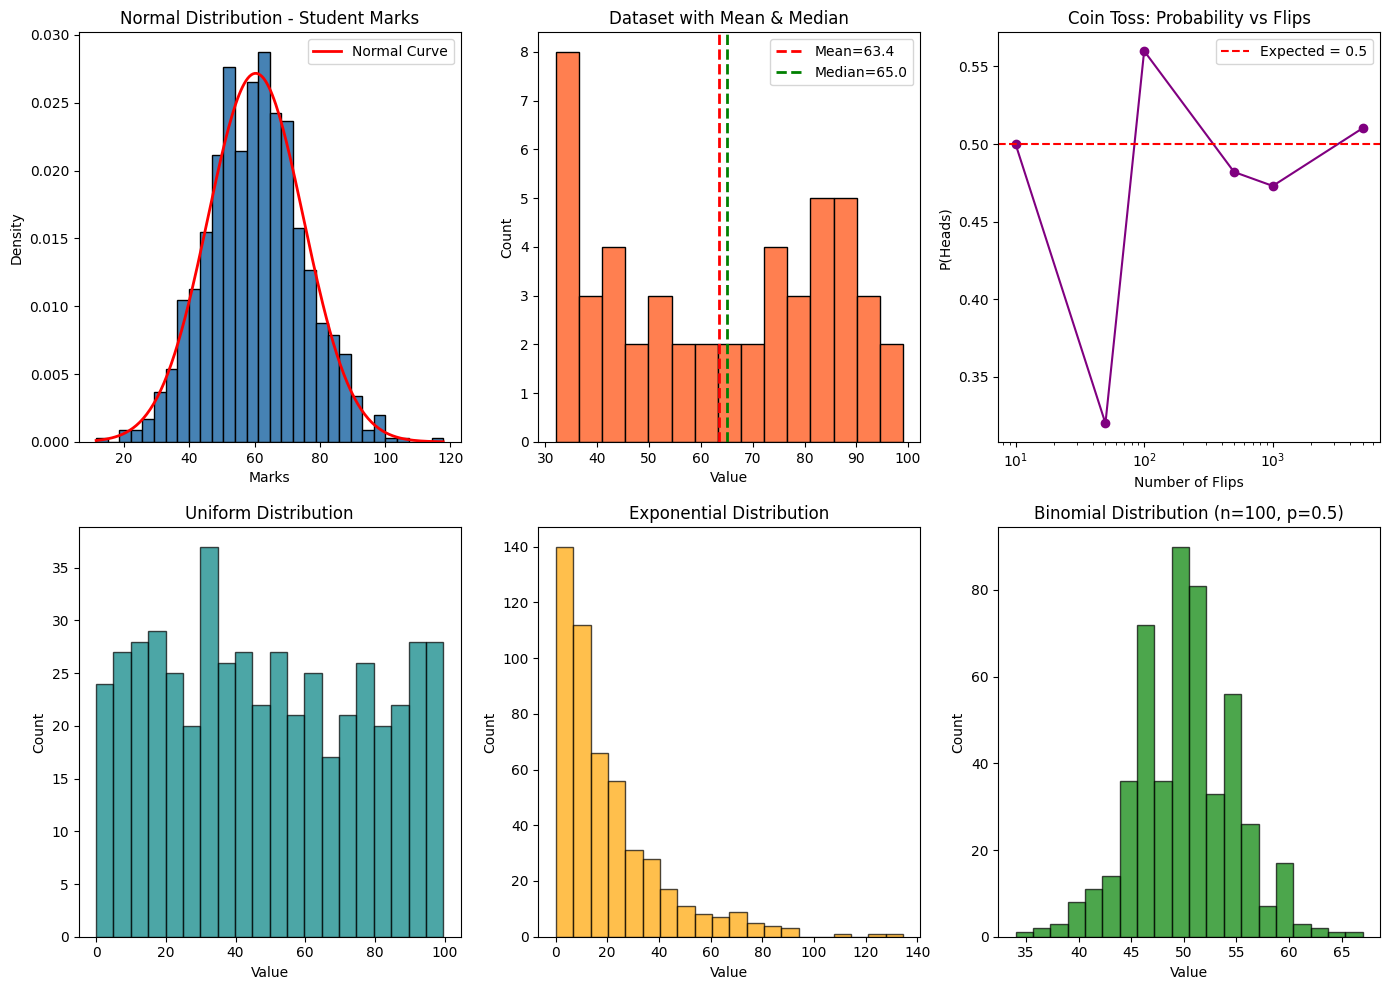


Total data points : 1000
Outliers (z > 3)  : 3
Normal range      : 16.25 to 104.33


In [2]:
# ============================================
# PROJECT 4: Probability & Statistics
# SPPU Data Science Lab - PCC-255-CAI
# Libraries: numpy, scipy, matplotlib
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

# =====================
# PART 1: Normal Distribution
# =====================
data = np.random.normal(loc=60, scale=15, size=1000)  # ← was n=1000, wrong keyword
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.hist(data, bins=30, color='steelblue', edgecolor='black', density=True)
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r-', linewidth=2, label='Normal Curve')
plt.title('Normal Distribution - Student Marks')
plt.xlabel('Marks'); plt.ylabel('Density'); plt.legend()

# =====================
# PART 2: Mean, Median, Variance, Std Dev
# =====================
dataset = np.random.randint(30, 100, 50)

mean   = np.mean(dataset)
median = np.median(dataset)
var    = np.var(dataset)
std    = np.std(dataset)

print("=== DESCRIPTIVE STATISTICS ===")
print(f"Mean     : {mean:.2f}")
print(f"Median   : {median:.2f}")
print(f"Variance : {var:.2f}")
print(f"Std Dev  : {std:.2f}")

plt.subplot(2, 3, 2)
plt.hist(dataset, bins=15, color='coral', edgecolor='black')
plt.axvline(mean,   color='red',    linestyle='--', linewidth=2, label=f'Mean={mean:.1f}')
plt.axvline(median, color='green',  linestyle='--', linewidth=2, label=f'Median={median:.1f}')
plt.title('Dataset with Mean & Median')
plt.xlabel('Value'); plt.ylabel('Count'); plt.legend()

# =====================
# PART 3: Coin Toss Simulation
# =====================
n_flips = [10, 50, 100, 500, 1000, 5000]
head_probs = []

for n in n_flips:
    tosses = np.random.choice(['H', 'T'], n)
    prob = np.sum(tosses == 'H') / n
    head_probs.append(prob)
    print(f"Flips: {n:5d} | Heads Probability: {prob:.4f}")

plt.subplot(2, 3, 3)
plt.plot(n_flips, head_probs, marker='o', color='purple')
plt.axhline(0.5, color='red', linestyle='--', label='Expected = 0.5')
plt.title('Coin Toss: Probability vs Flips')
plt.xlabel('Number of Flips'); plt.ylabel('P(Heads)'); plt.legend()
plt.xscale('log')

# =====================
# PART 4: Histogram of different distributions
# =====================
uniform = np.random.uniform(0, 100, 500)
expo    = np.random.exponential(scale=20, size=500)
binom   = np.random.binomial(n=100, p=0.5, size=500)

plt.subplot(2, 3, 4)
plt.hist(uniform, bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Uniform Distribution'); plt.xlabel('Value'); plt.ylabel('Count')

plt.subplot(2, 3, 5)
plt.hist(expo, bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.title('Exponential Distribution'); plt.xlabel('Value'); plt.ylabel('Count')

plt.subplot(2, 3, 6)
plt.hist(binom, bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Binomial Distribution (n=100, p=0.5)')
plt.xlabel('Value'); plt.ylabel('Count')

plt.tight_layout()
plt.savefig('probability_statistics.png', dpi=100)
plt.show()

# =====================
# PART 5: Z-score & Outlier Detection
# =====================
z_scores = np.abs(stats.zscore(data))
outliers = np.sum(z_scores > 3)
print(f"\nTotal data points : {len(data)}")
print(f"Outliers (z > 3)  : {outliers}")
print(f"Normal range      : {data.mean()-3*data.std():.2f} to {data.mean()+3*data.std():.2f}")